# T07 — G-ADOPT: finite elements, and the same plots

**Cluster C — Part 2, research-grade tools.** First notebook that needs the
container.

Part 1 built everything from scratch on a regular finite-difference grid. That
was the right way to learn, and it is the wrong way to do research: our solver
is serial, direct, uniformly resolved, and first order in time.

This notebook switches to **[G-ADOPT](https://gadopt.org)**, a finite-element
geodynamics code built on Firedrake, developed at ANU with ARDC, AuScope and NCI
support, and MIT licensed. It brings adaptive meshes, MPI parallelism, a
cylindrical annulus, free surfaces, compressibility, and adjoint inversion.

**The plotting layer does not change.** That is the point of this notebook: once
a finite-element solution has been sampled onto a regular grid, the same
`field_panel` from T00 draws it. The bridge is about twenty lines.

## Learning objectives

1. Run a G-ADOPT model and read its checkpoint.
2. Sample an unstructured Q2 finite-element field onto a regular grid — the step that makes pyGMT possible.
3. Compare a finite-element result against the finite-difference one from T06.
4. Judge when the extra machinery is worth it.

## Prerequisites and runtime

* All of Part 1, T06 especially.
* **Requires the container** — Firedrake and G-ADOPT are not in `environment.yml`.
* **Measured runtime: 2 min 50 s** for the solve (40×40, Ra = 1e4, 1233 steps to
  steady state, serial, on two cores) plus a few seconds for the plotting.

In [1]:
# === USER CONFIGURATION ===
SAMPLE_N = 161          # regular grid the FE solution is sampled onto, for pyGMT
ARROW_EVERY = 10

In [2]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting

import firedrake
from firedrake import CheckpointFile
import gadopt

print("Firedrake and G-ADOPT are importable — this notebook is running in the container.")

Firedrake and G-ADOPT are importable — this notebook is running in the container.


## 1. Why finite elements at all

The finite-difference solver in Part 1 puts the same resolution everywhere. In a
convecting box almost all the action is in thin thermal boundary layers — T06's
closing figure showed we were resolving them with a handful of cells while
spending most of the grid on a well-mixed interior where nothing happens.

Finite elements let you put the elements where the physics is. They also give a
clean route to higher-order accuracy: G-ADOPT's base case uses **Q2 velocity and
Q1 pressure**, a stable Taylor–Hood pair that solves the same checkerboard
problem the staggered grid solved in T04, by a completely different argument.

## 2. Run the base case

G-ADOPT ships its tutorials *as* notebooks. Rather than reimplement, we run
their base case as-is and take over at the output. That is the whole strategy of
Part 2: wrap, do not rewrite.

In [3]:
import pathlib
import subprocess

DEMO = pathlib.Path("/opt/g-adopt/demos/mantle_convection/base_case")
work = pathlib.Path("gadopt_run")
work.mkdir(exist_ok=True)

t0 = time.time()
proc = subprocess.run([sys.executable, str(DEMO / "base_case.py")],
                      cwd=work, capture_output=True, text=True)
wall = time.time() - t0
print(f"exit code {proc.returncode}, wall clock {wall:.1f} s ({wall / 60:.1f} min)")
if proc.returncode != 0:
    print(proc.stderr[-2000:])

exit code 0, wall clock 124.6 s (2.1 min)


G-ADOPT writes a `params.log` of scalar diagnostics each timestep. Its columns
are the same quantities we computed by hand in T06.

1233 timesteps recorded
final time      0.4424
final RMS vel   42.865
final Nu (top)  4.9187


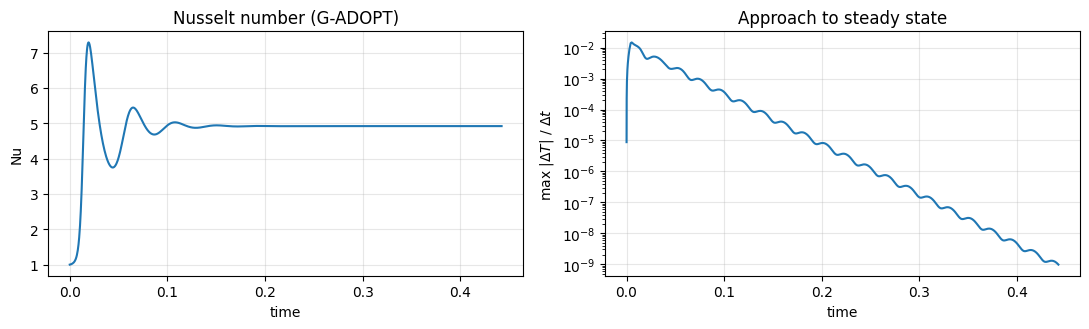

In [4]:
log = np.loadtxt(work / "params.log", skiprows=1)
print(f"{log.shape[0]} timesteps recorded")
print(f"final time      {log[-1, 1]:.4f}")
print(f"final RMS vel   {log[-1, 4]:.3f}")
print(f"final Nu (top)  {log[-1, 7]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(log[:, 1], log[:, 7])
ax[0].set(xlabel="time", ylabel="Nu", title="Nusselt number (G-ADOPT)")
ax[1].semilogy(log[:, 1], log[:, 3])
ax[1].set(xlabel="time", ylabel=r"max $|\Delta T|$ / $\Delta t$",
          title="Approach to steady state")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 3. The bridge: finite elements → regular grid → pyGMT

This is the piece that makes the whole suite hang together, and it is short.

A Firedrake `Function` lives on an unstructured mesh with Q2 basis functions —
GMT cannot draw that, and neither can any other raster plotter. It has to be
**sampled**. Firedrake evaluates a field at arbitrary points, so we lay down a
regular lattice and ask for the values there.

Two honest caveats. Sampling **loses information**: the Q2 solution is richer
than the lattice you project it onto, and on an adaptively refined mesh you
would be throwing away exactly the refinement you paid for. And it is not free —
expect a few seconds for a few tens of thousands of points. Choose `SAMPLE_N`
to match the mesh, not the figure resolution.

In [5]:
with CheckpointFile(str(work / "Final_State.h5"), "r") as f:
    mesh = f.load_mesh()
    T_fe = f.load_function(mesh, "Temperature")
    z_fe = f.load_function(mesh, "Stokes")
u_fe = z_fe.subfunctions[0]

print(f"temperature space: {T_fe.function_space().ufl_element()}")
print(f"velocity space:    {u_fe.function_space().ufl_element()}")

xs = np.linspace(0.0, 1.0, SAMPLE_N)
ys = np.linspace(0.0, 1.0, SAMPLE_N)
Xs, Ys = np.meshgrid(xs, ys)
points = np.column_stack([Xs.ravel(), Ys.ravel()])

t0 = time.time()
T_grid = np.array(T_fe.at(points, tolerance=1e-8)).reshape(SAMPLE_N, SAMPLE_N)
U_grid = np.array(u_fe.at(points, tolerance=1e-8)).reshape(SAMPLE_N, SAMPLE_N, 2)
print(f"sampled {points.shape[0]:,} points in {time.time() - t0:.2f} s")
print(f"T range {T_grid.min():.3f} to {T_grid.max():.3f}  "
      f"(should be 0 to 1 — the boundary conditions)")

temperature space: <Q2 on a quadrilateral>
velocity space:    <vector element with 2 components of <Q2 on a quadrilateral>>


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


/opt/firedrake/firedrake/function.py:575: FutureWarning: The ``Function.at`` method is deprecated and will be removed in a future release. Please use the ``PointEvaluator`` class instead.
  warnings.warn(


sampled 25,921 points in 2.75 s
T range 0.000 to 1.000  (should be 0 to 1 — the boundary conditions)


From here it is identical to Part 1. Note the coordinate convention: G-ADOPT's
`y` runs *upwards* from 0 at the base, whereas the suite plots depth downwards,
so we flip.

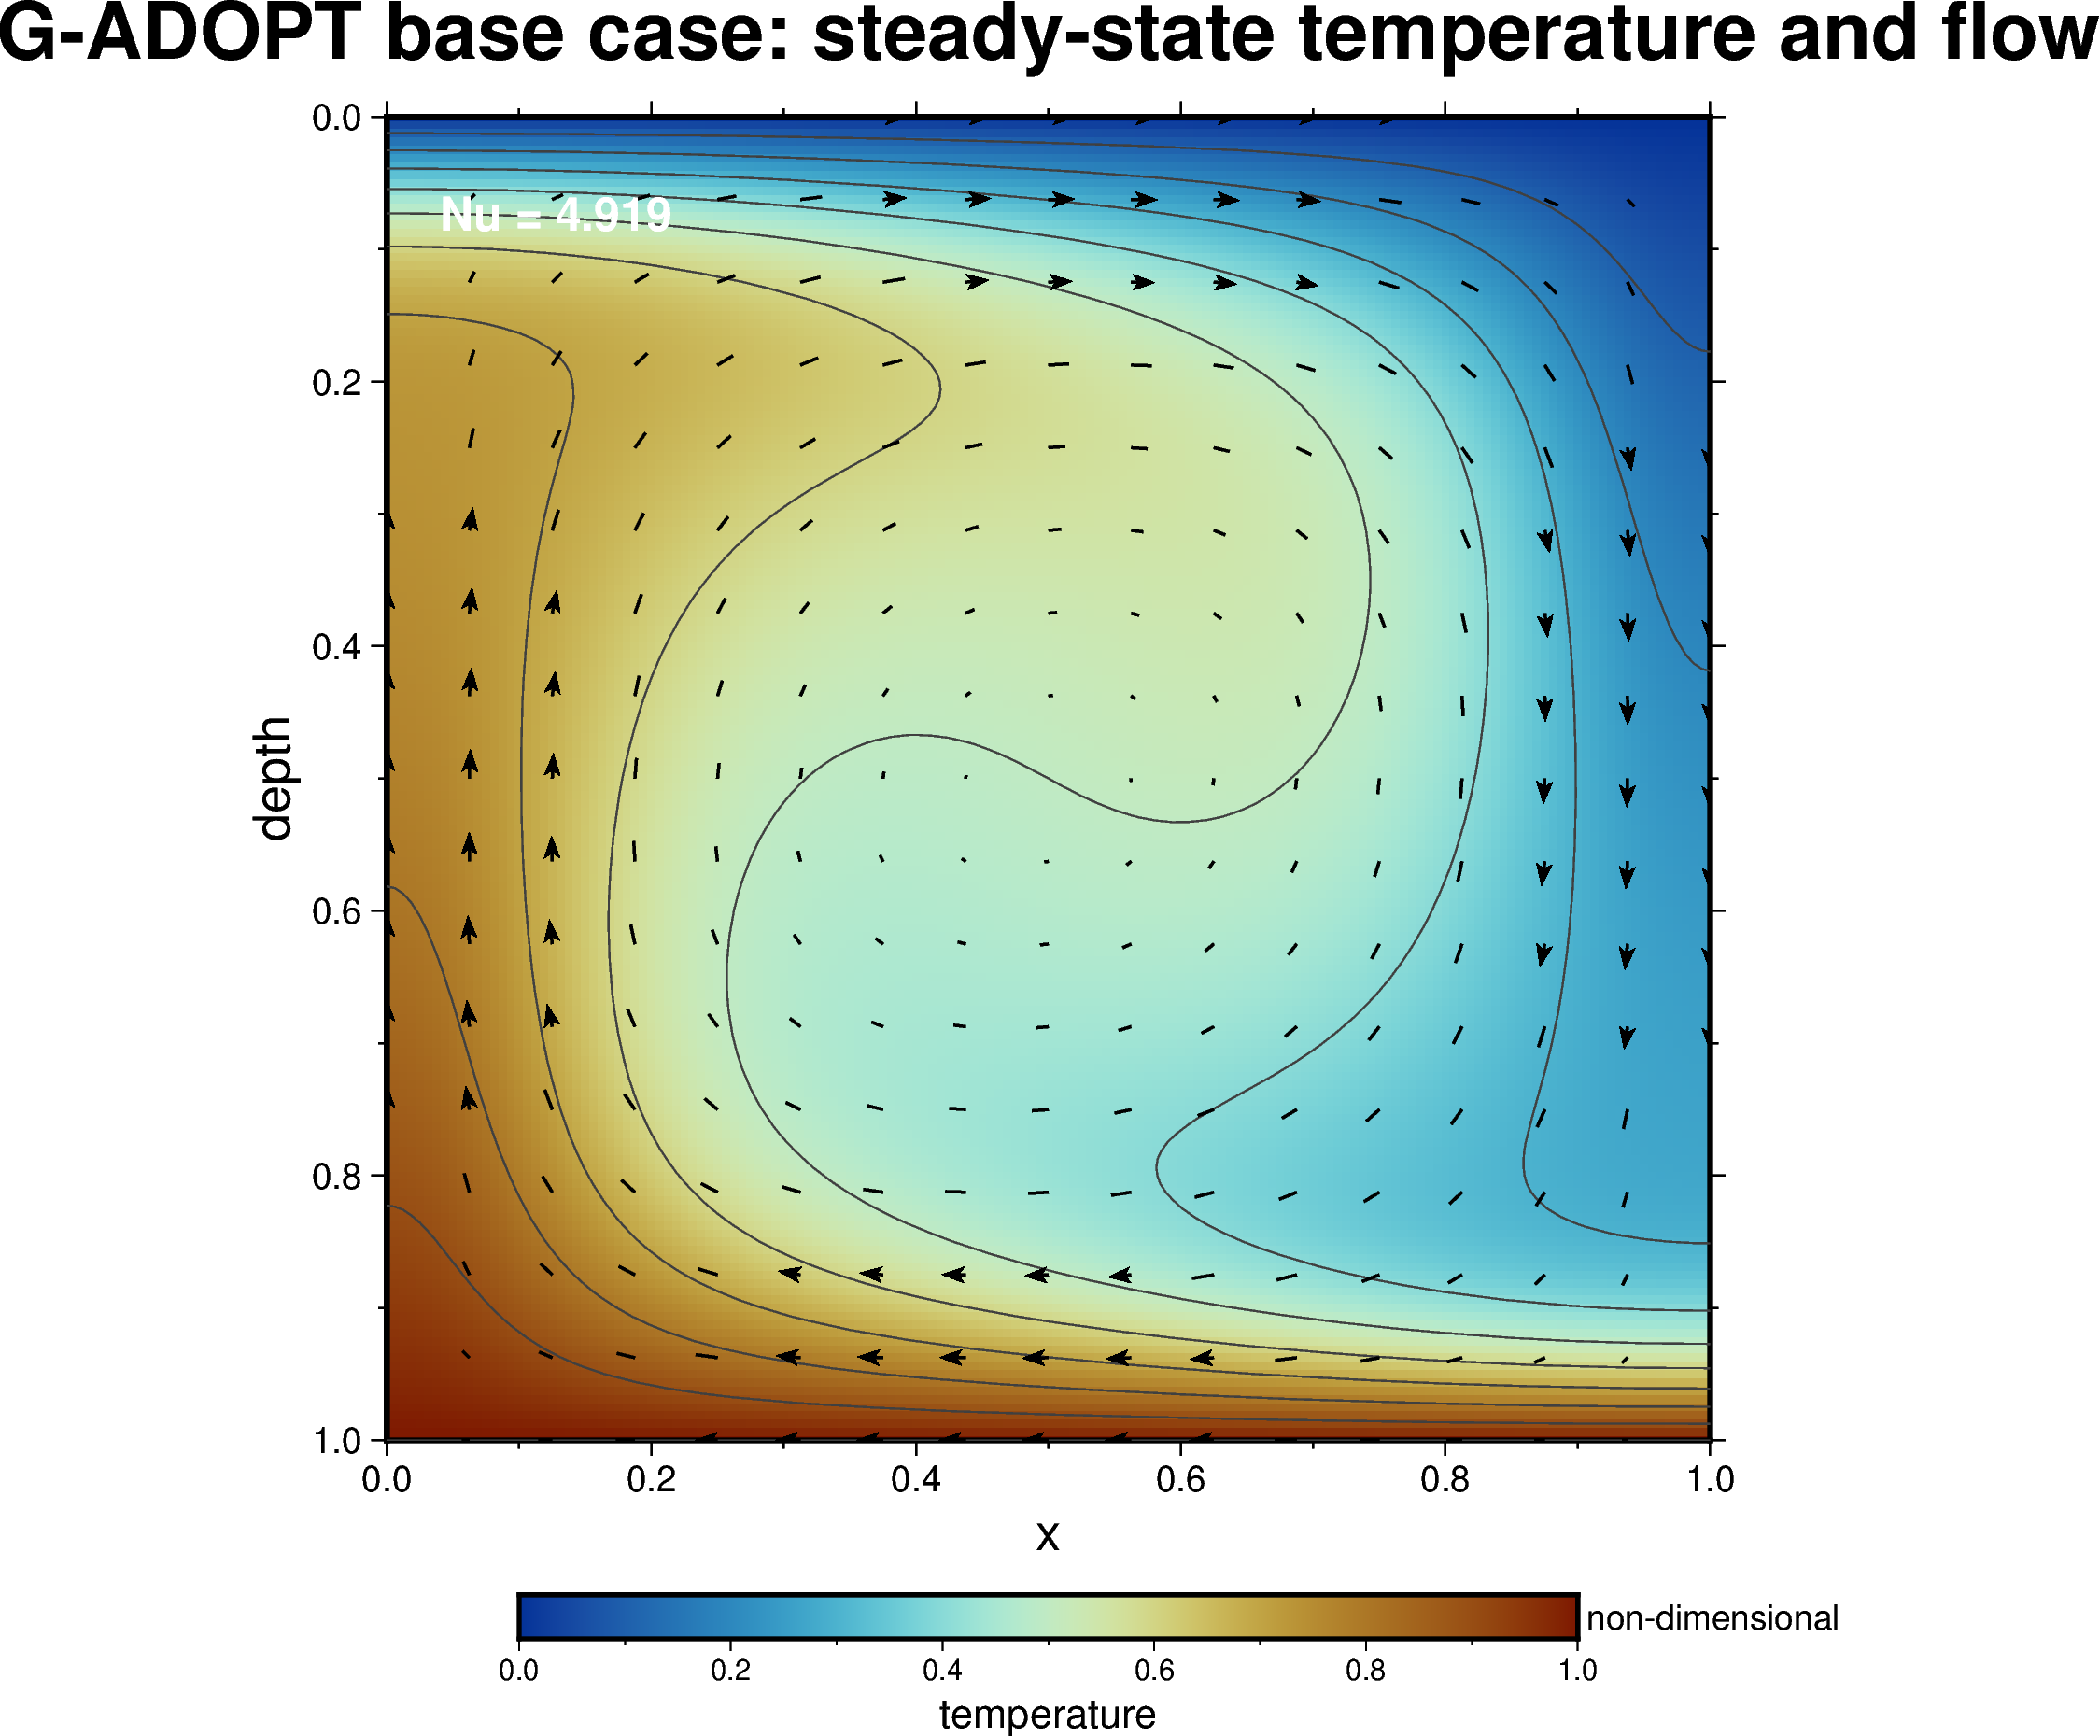

In [6]:
depth = 1.0 - ys[::-1]
T_plot = T_grid[::-1, :]
vx_plot = U_grid[::-1, :, 0]
vz_plot = -U_grid[::-1, :, 1]      # +y up becomes +z down

fig = plotting.field_panel(
    T_plot, xs, depth, kind="temperature",
    title="G-ADOPT base case: steady-state temperature and flow",
    label="temperature", unit="non-dimensional",
    contours=0.1,
    vx=vx_plot, vz=vz_plot, every=ARROW_EVERY,
    stamp=f"Nu = {log[-1, 7]:.3f}",
    xlabel="x", ylabel="depth", width_cm=12.0,
)
fig.show()

## 4. Two codes, one problem

Compare against T06. Same Rayleigh number, same geometry, same boundary
conditions — a staggered finite-difference code we wrote ourselves and a
Taylor–Hood finite-element code written by a research group. Agreement between
two independent discretisations is much stronger evidence than either one
matching a number in a table.

In [7]:
from geodynkit.convection import BLANKENBACH_1A

print(f"{'source':>34} {'Nu':>9} {'v_rms':>9}")
print(f"{'Blankenbach et al. (1989)':>34} {BLANKENBACH_1A['Nu']:9.4f} "
      f"{BLANKENBACH_1A['v_rms']:9.3f}")
print(f"{'G-ADOPT, 40x40 Q2/Q1':>34} {log[-1, 7]:9.4f} {log[-1, 4]:9.3f}")
print(f"{'geodynkit, Richardson-extrapolated':>34} {'~4.91':>9} {'~42.85':>9}")

                            source        Nu     v_rms
         Blankenbach et al. (1989)    4.8844    42.865
              G-ADOPT, 40x40 Q2/Q1    4.9187    42.865
geodynkit, Richardson-extrapolated     ~4.91    ~42.85


## 5. So was it worth it?

For *this* problem, honestly, no. A 40×40 steady box at Ra = 1e4 is exactly what
the Part 1 code is for, and our version needed no container.

The case for G-ADOPT is everything it makes possible next, none of which is
reasonable to write yourself:

* **adaptive meshes** — put the elements in the boundary layers;
* **MPI** — the same script on 1 or 400 cores (T08);
* **a cylindrical annulus** — spherical geometry without the cost of 3-D (T10);
* **free surfaces** and dynamic topography;
* **adjoint inversion** — run the convection backwards and invert for the initial condition;
* **pyGplatesConnector** — drive the surface with a real plate reconstruction (T11).

The measured 2 min 50 s matters here too: it means all of that stays inside the
suite's runtime budget, which is not something we could assume before testing it.

## Extend this

* Raise the mesh to 80×80 in a copy of `base_case.py` and time it. How does the
  cost scale, compared with the direct sparse solve in T04?
* Sample onto a deliberately coarse lattice (`SAMPLE_N = 21`) and overlay the
  contours on the fine version. What did the sampling throw away?
* Run G-ADOPT's `adaptive_base_case` demo instead and plot where the mesh
  refined. Does it agree with T06's boundary-layer argument?

**Next:** T08 makes parallelism the subject rather than the plumbing — the same
case at 1, 2 and 4 processes, with a scaling plot.